In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_sales = pd.read_csv(r"C:\Users\HP\Downloads\Retail Chain Analysis - Database\sales.csv")
df_customers = pd.read_csv(r"C:\Users\HP\Downloads\Retail Chain Analysis - Database\customers.csv")
df_products = pd.read_csv(r"C:\Users\HP\Downloads\Retail Chain Analysis - Database\products.csv")
df_regions = pd.read_csv(r"C:\Users\HP\Downloads\Retail Chain Analysis - Database\regions.csv")
df_reps = pd.read_csv(r"C:\Users\HP\Downloads\Retail Chain Analysis - Database\sales_reps.csv")

df_sales['sale_date'] = pd.to_datetime(df_sales['sale_date'])
df_customers['join_date'] = pd.to_datetime(df_customers['join_date'])

df = df_sales.merge(df_customers, on='customer_id', suffixes=('', '_cust')) \
             .merge(df_products, on='product_id') \
             .merge(df_regions, on='region_id') \
             .merge(df_reps, on='rep_id', suffixes=('', '_rep'))

df = df.drop(columns=['region_id_cust', 'region_id_rep', 'email_rep'])

df.shape

(1500, 25)

In [4]:
reference_date = df['sale_date'].max()

rfm = df[df['order_status'] == 'Delivered'].groupby('customer_name').agg(
    Recency=('sale_date', lambda x: (reference_date - x.max()).days),
    Frequency=('sale_id', 'count'),
    Monetary=('total_amount', 'sum')
).reset_index()

rfm.head()

,customer_name,Recency,Frequency,Monetary
0,Ananya Das,65,4,215.67
1,Ananya Gupta,19,2,245.77
2,Ananya Mehta,25,8,1173.67
3,Ananya Nair,29,8,1159.04
4,Ananya Pillai,17,6,1458.02


In [5]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=3, labels=[3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=3, labels=[1, 2, 3])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=3, labels=[1, 2, 3])

rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

def segment_customer(score):
    if score >= 8:
        return 'VIP'
    elif score >= 6:
        return 'Loyal'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

rfm['Segment'].value_counts()

Segment
At Risk    47
Loyal      47
VIP        44
Lost       22
Name: count, dtype: int64

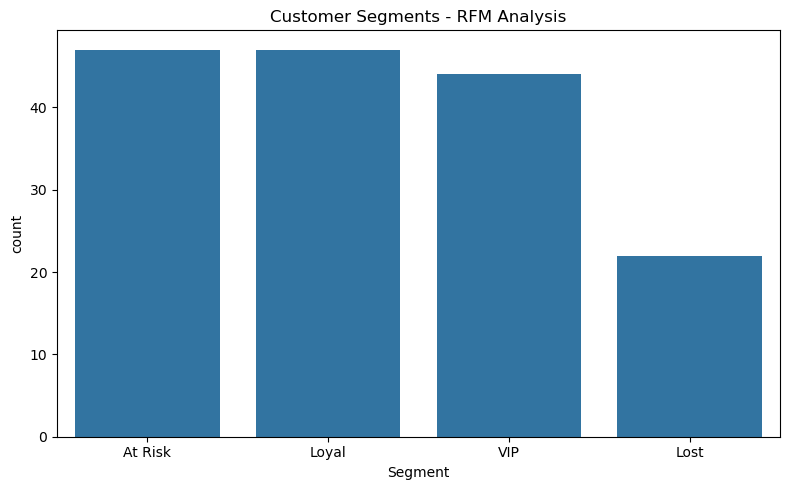

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=rfm['Segment'].value_counts().reset_index(), 
            x='Segment', y='count')
plt.title('Customer Segments - RFM Analysis')
plt.tight_layout()
plt.show()

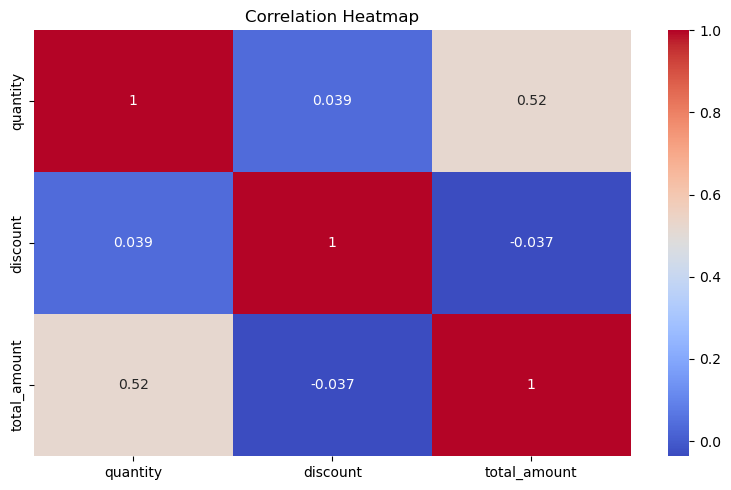

In [7]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[['quantity', 'discount', 'total_amount']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()